# Day 02 — Classical Machine Learning

## Objectives

Today I will:

- Load a tabular dataset using scikit-learn
- Split data using `train_test_split`
- Train Logistic Regression
- Train Decision Tree
- Compute Accuracy
- Compute Precision
- Compute Recall
- Compute F1 Score
- Plot confusion matrices
- Compare both models
- Write a short reflection

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

## 1. Load a Tabular Dataset

I will use the Breast Cancer dataset provided by scikit-learn.

The dataset contains:

- Input features (`X`)
- Target labels (`y`)

This is a binary classification problem.

In [12]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset loaded successfully.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target classes:", data.target_names)

Dataset loaded successfully.
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']


## 2. Train-Test Split

I will split the dataset into:

- 80% training data
- 20% testing data

The training data is used to train the models.

The testing data is kept unseen during training and is used to evaluate the models.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## 3. Train Logistic Regression

Logistic Regression is a supervised Machine Learning algorithm used for classification.

It learns patterns from the training data and predicts the class of unseen data.

In [14]:
logistic_model = LogisticRegression(
    max_iter=10000
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 4. Train Decision Tree

Decision Tree is a supervised Machine Learning algorithm that makes predictions by splitting data based on feature values.

It can be visualized as a sequence of decision questions.

In [15]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


## 5. Evaluate Logistic Regression

The Logistic Regression model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

In [16]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression")
print("===================")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

Logistic Regression
Accuracy : 0.9649
Precision: 0.9595
Recall   : 0.9861
F1 Score : 0.9726


## 6. Evaluate Decision Tree

The Decision Tree model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

In [17]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree
)

tree_recall = recall_score(
    y_test,
    y_pred_tree
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

print("Decision Tree")
print("=============")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")

Decision Tree
Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028
F1 Score : 0.9286


## 7. Model Comparison

The two models are compared using their:

- Accuracy
- Precision
- Recall
- F1 Score

F1 Score will be used as the main metric for deciding the overall winner because it considers both precision and recall.

In [18]:
print("MODEL COMPARISON")
print("================")

print("\nLogistic Regression")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

print("\nDecision Tree")
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")

if logistic_f1 > tree_f1:
    winner = "Logistic Regression"
elif tree_f1 > logistic_f1:
    winner = "Decision Tree"
else:
    winner = "Tie"

print("\nWinner based on F1 Score:", winner)

MODEL COMPARISON

Logistic Regression
Accuracy : 0.9649
Precision: 0.9595
Recall   : 0.9861
F1 Score : 0.9726

Decision Tree
Accuracy : 0.9123
Precision: 0.9559
Recall   : 0.9028
F1 Score : 0.9286

Winner based on F1 Score: Logistic Regression


## 8. Confusion Matrix — Logistic Regression

A confusion matrix shows the relationship between the actual classes and the predicted classes.

It contains:

- True Positive
- True Negative
- False Positive
- False Negative

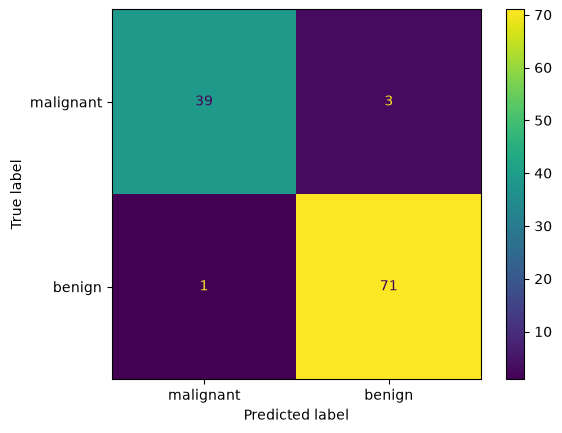

In [19]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic,
    display_labels=data.target_names
)

## 9. Confusion Matrix — Decision Tree

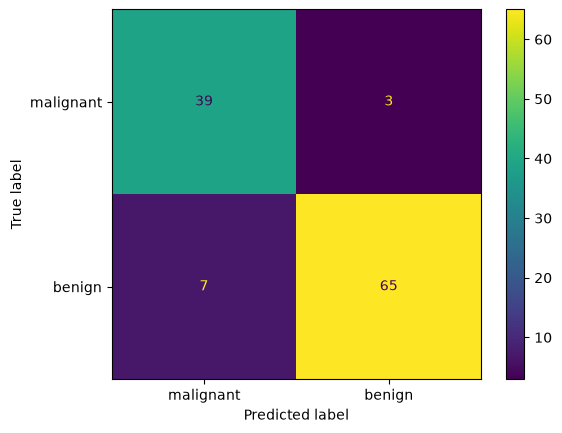

In [20]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    display_labels=data.target_names
)

## 10. Final Reflection

### Which model won?

Based on the F1 Score, the winning model was:

**Logistic Regression**

### Why?

Logistic Regression achieved a better F1 Score than the Decision Tree on the test dataset.

I compared both Logistic Regression and Decision Tree using accuracy, precision, recall, and F1 Score. Logistic Regression performed better overall based on the F1 Score.

### What I learned

I learned how to load a tabular dataset using scikit-learn and split it into training and testing data.

I learned how to train Logistic Regression and Decision Tree classification models.

I also learned how to calculate accuracy, precision, recall, and F1 Score to evaluate classification models.

Finally, I learned how to use confusion matrices to understand the correct and incorrect predictions made by each model.